# <font color="blue">Project1: Virtual Makeup </font>
We have already seen interesting applications of facial features and landmarks such as aging, beardify, face swap etc.

In this project, you will build features for a Virtual Makeup application! Given below are a few features that are required to be built in the application. 

1. Apply Lipstick
1. Apply Blush
1. Apply Eye-Liners or Eye-Lashes
1. Apply Glasses
1. Apply Eye Color ( Lens Color)
1. Apply Hat/Cap
1. Apply Ear-Rings
1. Change Hair Color

### <font color="green">Your Task</font>
Implement any 2 features from the list above

We have provided a sample image. You can use your own image for experimentation as well as come up with other interesting features.

### <font color="green">Submission</font>
Once you are done, you have to either make a video or submit a writeup explaining the main part of the code. For video, upload it to youtube or any other video sharing service and provide the link in the form given below. For Text writeup, you can create a blog or write it in a doc file and submit.

### <font color="green">Marks Distribution</font>

1. Feature 1: 35 marks
2. Video/Writeup for Feature 1: 15 marks
3. Feature 2: 35 marks
4. Video/Writeup for Feature 2: 15 marks

In [1]:
import cv2,sys,dlib,time,math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

/usr/local/lib/python3.6/site-packages/matplotlib/font_manager.py:281: UserWarning: Matplotlib is building the font cache using fc-list. This may take a moment.
  'Matplotlib is building the font cache using fc-list. '


Load faceBlendCommon file to use common functions.

In [2]:
import sys
sys.path.append('../resource/lib/public')
import faceBlendCommon as fbc

In [3]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8.0,8.0)
matplotlib.rcParams['image.cmap'] = 'gray'
matplotlib.rcParams['image.interpolation'] = 'bilinear'

# <font color="blue">Load landmark detector</font>
We have provided code for loading the model for landmark detector.

In [4]:
# Landmark model location
PREDICTOR_PATH =  "../resource/lib/publicdata/models/shape_predictor_68_face_landmarks.dat"

# Get the face detector
faceDetector = dlib.get_frontal_face_detector()
# The landmark detector is implemented in the shape_predictor class
landmarkDetector = dlib.shape_predictor(PREDICTOR_PATH)

# <font color="blue">Read Image</font>
We load the image and convert it to RGB format so that it can be used by Dlib and also for displaying using matplotlib.

### <font color="red">You can also use any other image.</font> 

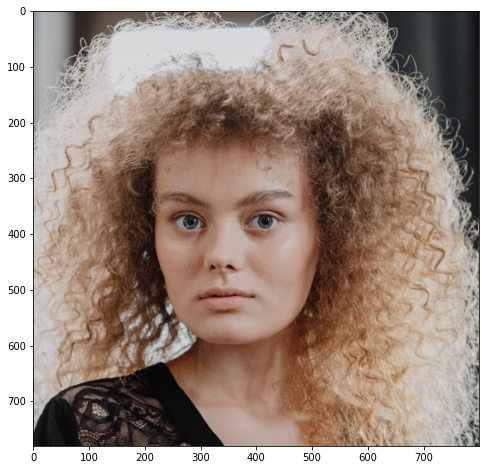

In [5]:
im = cv2.imread("../resource/lib/publicdata/images/girl-no-makeup.jpg")

imDlib = cv2.cvtColor(im,cv2.COLOR_BGR2RGB)
plt.imshow(imDlib)

# <font color="blue">Calculate Landmarks</font>
We are providing code for calculating the landmarks in this section. So that you can focus on the feature implementation.

In [6]:
points = fbc.getLandmarks(faceDetector, landmarkDetector, imDlib)
print(points)

[(216, 375), (217, 411), (224, 446), (233, 480), (242, 515), (258, 547), (283, 574), (313, 594), (350, 600), (390, 595), (430, 579), (464, 557), (488, 524), (501, 487), (508, 447), (513, 408), (514, 369), (223, 343), (241, 326), (268, 325), (293, 333), (317, 346), (362, 345), (389, 331), (418, 321), (449, 321), (474, 336), (338, 374), (337, 397), (335, 419), (333, 442), (315, 465), (326, 468), (337, 471), (351, 468), (364, 465), (252, 378), (268, 368), (289, 369), (307, 385), (287, 390), (266, 389), (382, 384), (401, 369), (423, 367), (441, 375), (426, 387), (404, 389), (293, 517), (310, 503), (327, 496), (340, 500), (353, 496), (376, 502), (401, 514), (377, 528), (356, 535), (341, 536), (326, 535), (310, 530), (303, 516), (327, 512), (340, 512), (354, 511), (391, 513), (354, 512), (341, 513), (327, 513)]


# <font color="blue">TODO</font>
You have to implement 2 features from the above list. You can also think about a new feature and implement. 


# <font color="blue">Feature 1: Apply Lipstick</font>
Write code for the first feature you want to implement from the above list. Display the output image after writing the code.

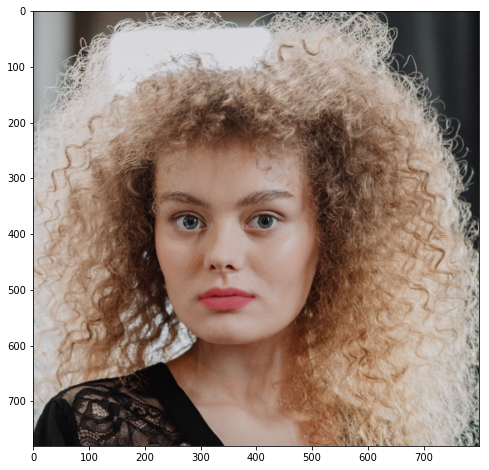

In [7]:
# Set color and alpha of lipstick
COLOR = (56, 27, 179)
ALPHA = 0.5
# Create mask
mask = np.zeros_like(im)
# Select outer edge of lips
outer_lips = np.array(points[48:60])
outer_lips = outer_lips.reshape((-1, 1, 2))
# Select inner edge of lips
inner_lips = np.array(points[60:68])
inner_lips = inner_lips.reshape((-1, 1, 2))
# Draw white polygon around outer edge
cv2.fillPoly(mask, [outer_lips], (255, 255, 255))
# Draw black polygon around inner edge
cv2.fillPoly(mask, [inner_lips], (0, 0, 0))
# Blur the mask
mask = cv2.GaussianBlur(mask, (15, 15), 0)
# Apply alpha to mask
mask = mask / 255 * ALPHA
# Blend images
result = mask * np.array(COLOR) / 255 + (im / 255) * (1 - mask)
result = np.uint8(result * 255)
# Show result
plt.imshow(result[..., ::-1])
plt.show()

# <font color="blue">Feature 2: Apply Blush</font>
Write code for the second feature you want to implement from the above list. Display the output image after writing the code.

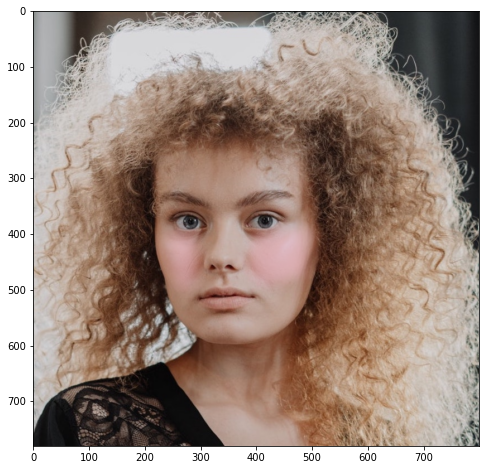

In [8]:
# Set color and alpha of blush
COLOR = (207, 187, 244)
ALPHA = 0.5
# Create mask
mask = np.zeros_like(im)
# Select left cheek
left_cheek = []
for i in [0, 39, 31, 48, 4]:
    left_cheek.append(points[i])
left_cheek = np.array(left_cheek)
left_cheek = left_cheek.reshape((-1, 1, 2))
# Select right cheek
right_cheek = []
for i in [16, 42, 35, 54, 13]:
    right_cheek.append(points[i])
right_cheek = np.array(right_cheek)
right_cheek = right_cheek.reshape((-1, 1, 2))
# Draw white polygon around both cheeks
cv2.fillPoly(mask, [left_cheek], (255, 255, 255))
cv2.fillPoly(mask, [right_cheek], (255, 255, 255))
# Erode the mask
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
mask = cv2.erode(mask, kernel)
# Blur the mask
mask = cv2.GaussianBlur(mask, (75, 75), 0)
# Apply alpha to mask
mask = mask / 255 * ALPHA
# Blend images
result = mask * np.array(COLOR) / 255 + (im / 255) * (1 - mask)
result = np.uint8(result * 255)
# Show result
plt.imshow(result[..., ::-1])
plt.show()